In [1]:
from utils import *
NOTEBOOK_ID = '05'

In [2]:
data_df = pd.read_csv(f'{EXPERIMENT_DIR}/experimental_data.csv')
gfp_df = pd.concat([
    pd.read_csv(f'{EXPERIMENT_DIR}/plate_reader/250_500_1k_internal_controls_fluo.csv'),
    pd.read_csv(f'{EXPERIMENT_DIR}/plate_reader/2k_internal_controls_fluo.csv')
]).reset_index(drop=True).drop(columns=['Unnamed: 0.1','Unnamed: 0','index']).rename(columns={'tileID':'tile_ID'})
merged_df = data_df.merge(gfp_df,on='tile_ID')
merged_df.head()

,tile_ID,ratio_rep1,coverage_rep1,ratio_rep2,coverage_rep2,iscontrol,log_cov_rep1,log_cov_rep2,dataset,ratio_rep3,...,ncbi_id,tax_id,normRFP_mean,lognormRFP_mean,normRFP_std,lognormRFP_std,normGFP_mean,lognormGFP_mean,normGFP_std,lognormGFP_std
0,A1,0.759964,0.001345,0.697140,0.001065,yes,-2.871267,-2.972788,500,NaN,...,NaN,1770265.0,0.193568,-2.560759,0.091201,0.825294,NaN,NaN,NaN,NaN
1,A1,0.678302,0.014918,0.636914,0.015860,yes,-1.826291,-1.799709,250,0.610058,...,NaN,1770265.0,0.193568,-2.560759,0.091201,0.825294,NaN,NaN,NaN,NaN
2,A1,0.420913,0.001232,0.558164,0.001573,yes,-2.909379,-2.803193,1K,NaN,...,NaN,1770265.0,0.193568,-2.560759,0.091201,0.825294,NaN,NaN,NaN,NaN
3,A1,0.677157,0.000050,0.222862,0.000011,yes,-4.304599,-4.951321,2K,NaN,...,NaN,1770265.0,0.193568,-2.560759,0.091201,0.825294,NaN,NaN,NaN,NaN
4,A6I62_gp2-081,1.576038,0.004681,1.636974,0.004370,no,-2.329627,-2.359567,500,NaN,...,NC_029906,1848040.0,30.192751,3.390535,5.835960,0.188684,4.355298,5.397261,0.841836,0.200671


0.9750694705084277


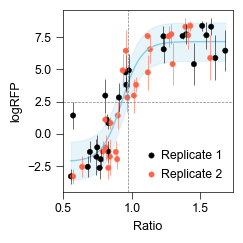

In [3]:
tmp_df = merged_df.query('dataset == "250" and iscontrol == "yes"').melt(
    id_vars=['tile_ID', 'lognormRFP_mean', 'lognormRFP_std'],
    value_vars=['ratio_rep1', 'ratio_rep2'],
    value_name='ratio'
)
tmp_df['variable'] = tmp_df['variable'].map({'ratio_rep1':'Replicate 1','ratio_rep2':'Replicate 2'})

x_fit, y_fit, y_lower, y_upper, x_intercept, residual_std, x0, y_midpoint, x_upper_bound= fit_sigmoid(x_data=tmp_df['ratio'].values.astype(float),y_data=tmp_df['lognormRFP_mean'].values.astype(float) )

plt.figure(figsize=(2.5, 2.5))
sns.lineplot(x=x_fit, y=y_fit, color='skyblue', linewidth=1)
plt.fill_between(x_fit, y_lower, y_upper, color='skyblue', alpha=0.2)
g = sns.scatterplot(
    data=tmp_df,
    x='ratio', y='lognormRFP_mean', s=15, palette=['black','tomato'], hue='variable', edgecolor=None,
)
group1 = tmp_df.query('variable == "Replicate 1"')
group2 = tmp_df.query('variable == "Replicate 2"')

plt.errorbar(group1['ratio'], group1['lognormRFP_mean'], yerr=group1['lognormRFP_std'], fmt='none', ecolor='black', alpha=0.8, linewidth=0.5)
plt.errorbar(group2['ratio'], group2['lognormRFP_mean'], yerr=group2['lognormRFP_std'], fmt='none', ecolor='tomato', alpha=0.8, linewidth=0.5)
plt.axhline(y=y_midpoint, color='grey', linestyle='--',linewidth=0.5)
plt.axvline(x=x_upper_bound, color='grey', linestyle='--',linewidth=0.5)
g.set(xlabel='Ratio', ylabel='logRFP')
g.legend(frameon=False,handlelength=0.0)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-sigmoid_250.svg',**FIG_PARAMS)

1.0246787247457614


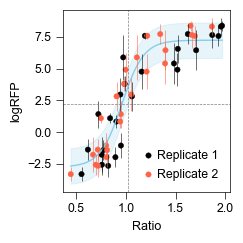

In [4]:
tmp_df = merged_df.query('dataset == "500" and iscontrol == "yes"').melt(
    id_vars=['tile_ID', 'lognormRFP_mean', 'lognormRFP_std'],
    value_vars=['ratio_rep1', 'ratio_rep2'],
    value_name='ratio'
)
tmp_df['variable'] = tmp_df['variable'].map({'ratio_rep1':'Replicate 1','ratio_rep2':'Replicate 2'})
tmp_df = tmp_df.drop(44)

x_fit, y_fit, y_lower, y_upper, x_intercept, residual_std, x0, y_midpoint, x_upper_bound= fit_sigmoid(x_data=tmp_df['ratio'].values.astype(float),y_data=tmp_df['lognormRFP_mean'].values.astype(float) )

plt.figure(figsize=(2.5, 2.5))
sns.lineplot(x=x_fit, y=y_fit, color='skyblue', linewidth=1)
plt.fill_between(x_fit, y_lower, y_upper, color='skyblue', alpha=0.2)
g = sns.scatterplot(
    data=tmp_df,
    x='ratio', y='lognormRFP_mean', s=15, palette=['black','tomato'], hue='variable', edgecolor=None,
)
group1 = tmp_df.query('variable == "Replicate 1"')
group2 = tmp_df.query('variable == "Replicate 2"')
plt.errorbar(group1['ratio'], group1['lognormRFP_mean'], yerr=group1['lognormRFP_std'], fmt='none', ecolor='black', alpha=0.8, linewidth=0.5)
plt.errorbar(group2['ratio'], group2['lognormRFP_mean'], yerr=group2['lognormRFP_std'], fmt='none', ecolor='tomato', alpha=0.8, linewidth=0.5)
plt.axhline(y=y_midpoint, color='grey', linestyle='--',linewidth=0.5)
plt.axvline(x=x_upper_bound, color='grey', linestyle='--',linewidth=0.5)
g.set(xlabel='Ratio', ylabel='logRFP')
g.legend(frameon=False,handlelength=0.0)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-sigmoid_500.svg',**FIG_PARAMS)

0.9671268810104781


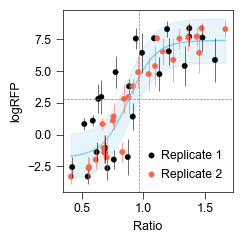

In [5]:
tmp_df = merged_df.query('dataset == "1K" and iscontrol == "yes"').melt(
    id_vars=['tile_ID', 'lognormRFP_mean', 'lognormRFP_std'],
    value_vars=['ratio_rep1', 'ratio_rep2'],
    value_name='ratio'
)
tmp_df['variable'] = tmp_df['variable'].map({'ratio_rep1':'Replicate 1','ratio_rep2':'Replicate 2'})

x_fit, y_fit, y_lower, y_upper, x_intercept, residual_std, x0, y_midpoint, x_upper_bound= fit_sigmoid(x_data=tmp_df['ratio'].values.astype(float),y_data=tmp_df['lognormRFP_mean'].values.astype(float) )

plt.figure(figsize=(2.5, 2.5))
sns.lineplot(x=x_fit, y=y_fit, color='skyblue', linewidth=1)
plt.fill_between(x_fit, y_lower, y_upper, color='skyblue', alpha=0.2)
g = sns.scatterplot(
    data=tmp_df,
    x='ratio', y='lognormRFP_mean', s=15, palette=['black','tomato'], hue='variable', edgecolor=None,
)

group1 = tmp_df.query('variable == "Replicate 1"')
group2 = tmp_df.query('variable == "Replicate 2"')
plt.errorbar(group1['ratio'], group1['lognormRFP_mean'], yerr=group1['lognormRFP_std'], fmt='none', ecolor='black', alpha=0.8, linewidth=0.5)
plt.errorbar(group2['ratio'], group2['lognormRFP_mean'], yerr=group2['lognormRFP_std'], fmt='none', ecolor='tomato', alpha=0.8, linewidth=0.5)
plt.axhline(y=y_midpoint, color='grey', linestyle='--',linewidth=0.5)
plt.axvline(x=x_upper_bound, color='grey', linestyle='--',linewidth=0.5)
g.set(xlabel='Ratio', ylabel='logRFP')
g.legend(frameon=False,handlelength=0.0)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-sigmoid_1K.svg',**FIG_PARAMS)

1.0934882543970346


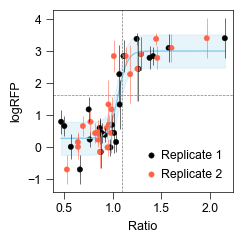

In [6]:
tmp_df = merged_df.query('dataset == "2K" and iscontrol == "no"').melt(
    id_vars=['tile_ID', 'lognormRFP_mean', 'lognormRFP_std'],
    value_vars=['ratio_rep1', 'ratio_rep2'],
    value_name='ratio'
)
tmp_df['variable'] = tmp_df['variable'].map({'ratio_rep1':'Replicate 1','ratio_rep2':'Replicate 2'})

x_fit, y_fit, y_lower, y_upper, x_intercept, residual_std, x0, y_midpoint, x_upper_bound= fit_sigmoid(x_data=tmp_df['ratio'].values.astype(float),y_data=tmp_df['lognormRFP_mean'].values.astype(float) )

plt.figure(figsize=(2.5, 2.5))
sns.lineplot(x=x_fit, y=y_fit, color='skyblue', linewidth=1)
plt.fill_between(x_fit, y_lower, y_upper, color='skyblue', alpha=0.2)
g = sns.scatterplot(
    data=tmp_df,
    x='ratio', y='lognormRFP_mean', s=15, palette=['black','tomato'], hue='variable', edgecolor=None,
)
group1 = tmp_df.query('variable == "Replicate 1"')
group2 = tmp_df.query('variable == "Replicate 2"')
plt.errorbar(group1['ratio'], group1['lognormRFP_mean'], yerr=group1['lognormRFP_std'], fmt='none', ecolor='black', alpha=0.8, linewidth=0.5)
plt.errorbar(group2['ratio'], group2['lognormRFP_mean'], yerr=group2['lognormRFP_std'], fmt='none', ecolor='tomato', alpha=0.8, linewidth=0.5)
plt.axhline(y=y_midpoint, color='grey', linestyle='--',linewidth=0.5)
plt.axvline(x=x_upper_bound, color='grey', linestyle='--',linewidth=0.5)
g.set(xlabel='Ratio', ylabel='logRFP')
g.legend(frameon=False,handlelength=0.0)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-sigmoid_2K.svg',**FIG_PARAMS)

In [7]:
out_file = f'{ANALYSIS_DIR}/experimental_data_fitted.csv'
if not os.path.isfile(out_file):
    data_df['is_activator'] = False
    threshold_dict = {
        '250': 0.9750694705084277,
        '500': 1.0246787247457614,
        '1K': 0.9671268810104781,
        '2K': 1.0934882543970346
    }
    for dataset, threshold in threshold_dict.items():
        mask = (
            (data_df['dataset'] == dataset) &
            ((data_df['ratio_rep1'] > threshold) | (data_df['ratio_rep2'] > threshold))
        )
        data_df.loc[mask, 'is_activator'] = True
    data_df.to_csv(out_file,index=False)